# Test notebook for scirpy usage
This notebook is the analog to the Colab created by Gregor S. for the demonstration of scirpy.datasets function usage:

https://colab.research.googl540656
e.com/drive/15HIYGsSBHkDV399KSchv2QEyBzheL6fW?usp=sharing



In [1]:
import sys
sys.path.append('..')


import muon as mu
import numpy as np
import scanpy as sc
import pandas as pd
import scirpy as ir

from tqdm import tqdm

# from iggytop.adapters.utils import AnnDataKG
# from biocypher.output.in_memory._airr_to_anndata import AIRRtoAnnDataKG as AnnDataKG

sc.set_figure_params(figsize=(4, 4))
sc.settings.verbosity = 2  # verbosity: errors (0), warnings (1), info (2), hints (3)

/home/dego/iggytop/.venv/lib/python3.11/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


## Data import and preprocessing

Loading example data and performing minimal preprocessing to get rid of "noise" data and further ignoring transcriptomic data preprocessing as we will not use it in this notebook. Incomplete cells ("orphan") or potential doublets ("multichain") are removed, which is common practice scAIRR-analysis. Refer to the data import tutorial and 3k T cell analysis tutorial for more comprehensive use-cases.

In [2]:
mdata = ir.datasets.wu2020_3k()
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: ~np.isin(x, ["orphan VDJ", "orphan VJ", "multichain"]))

Filtering chains...
Indexing VJ chains...


/home/dego/iggytop/.venv/lib/python3.11/site-packages/anndata/utils.py:362: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)
/home/dego/iggytop/.venv/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/dego/iggytop/.venv/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which 

Indexing VDJ chains...
build result array
Stored result in `mdata.obs["airr:receptor_type"]`.
Stored result in `mdata.obs["airr:receptor_subtype"]`.
Stored result in `mdata.obs["airr:chain_pairing"]`.


## Clonotype clustering

Clustering is performed here by calculating distances between individual sequences based on the BLOSUM62 matrix (metric = "alignment") and choosing an appropriate cutoff. This will cluster similar TCR sequences with a distance below the chosen cutoff, which are likely to recognize similar antigens. For more information regarding different distance metrics and how receptor_arms and dual_ir affects the clustering algorithm please refer to the 3k T cell tutorial. However, the following three consecutive function calls are always required:

Computing sequence x sequence distance matrix for VJ sequences.
block size set to 50


  0%|          | 0/496 [00:00<?, ?it/s]

Computing sequence x sequence distance matrix for VDJ sequences.
block size set to 50


  0%|          | 0/496 [00:00<?, ?it/s]

Initializing lookup tables. 
Computing clonotype x clonotype distances.
Stored result in `mdata.obs["airr:cc_aa_alignment"]`.
Stored result in `mdata.obs["airr:cc_aa_alignment_size"]`.


/home/dego/iggytop/.venv/lib/python3.11/site-packages/scirpy/pl/_clonotypes.py:179: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if f"X_{basis}" not in params.adata.obsm_keys():


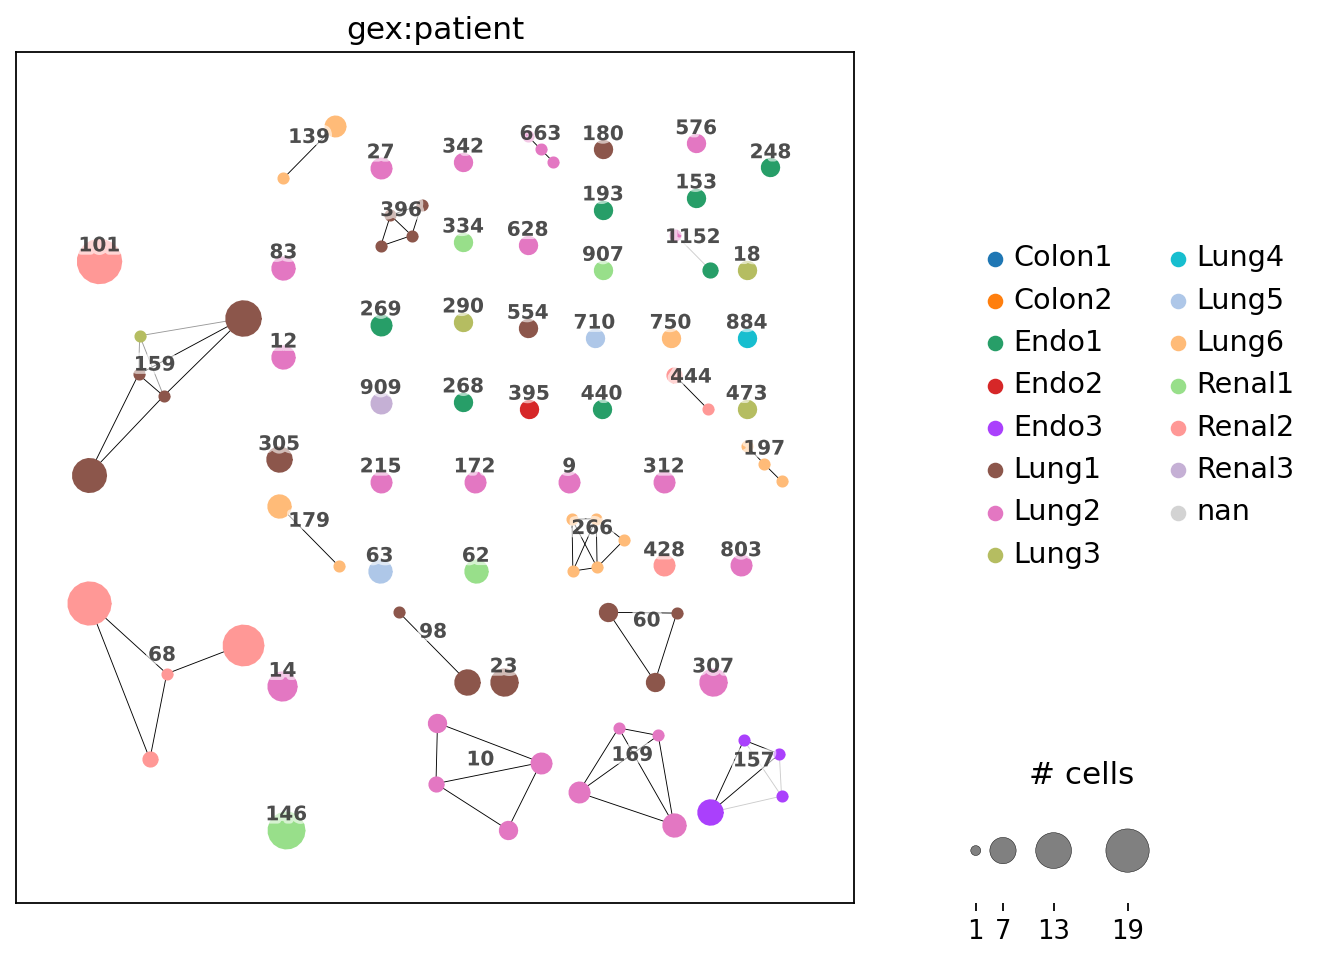

In [3]:
ir.pp.ir_dist(
    mdata,
    metric="alignment",
    sequence="aa",
    cutoff=15)

ir.tl.define_clonotype_clusters(mdata,
                                sequence="aa",
                                metric="alignment",
                                receptor_arms="all",
                                dual_ir="any")

#min_cells = 3 will only plot clonotype clusters with a size >= 3
ir.tl.clonotype_network(mdata, min_cells=3, sequence="aa", metric="alignment")

_ = ir.pl.clonotype_network(mdata, color="gex:patient", label_fontsize=9, panel_size=(7, 7), base_size=20)

# save figure as a png
#plt.savefig("clonotype_network.png", bbox_inches="tight")

## Load merged Iggytop data

In [4]:
import scirpy as ir

from datetime import datetime
from scirpy.pp import index_chains

In [5]:

cache_dir = "/home/dego/.cache/iggytop_w10X"
dedup_path = f"{cache_dir}/deduplicated_anndata.h5ad"
pd.set_option('display.max_colwidth', None)

# Load data
adata = sc.read_h5ad(dedup_path)
index_chains(adata)

adata.uns["DB"] = {"name": "Iggytop", "date_downloaded": datetime.now().isoformat()}

# # store cache
# os.makedirs(os.path.dirname(os.path.abspath(cache_path)), exist_ok=True)
# adata.write_h5ad(cast(os.PathLike, cache_path))file

Filtering chains...
Indexing VJ chains...
Indexing VDJ chains...
build result array


In [6]:
ir.get.airr(adata, airr_variable = ["v_call","j_call", "junction_aa"], chain = ["VDJ_1"]).head(5)

,VDJ_1_v_call,VDJ_1_j_call,VDJ_1_junction_aa
cell_id,,,
0_ITRAP,TRBV12-3,TRBJ2-2,CASSFSGNTGELFF
1_ITRAP,TRBV27,TRBJ2-2,CASSPHFQVDTGELFF
2_ITRAP,TRBV19,TRBJ2-7,CASSARSSYEQYF
3_ITRAP,TRBV7-3,TRBJ2-2,CASSLGTSGGTGELFF
4_ITRAP,TRBV7-9,TRBJ2-7,CASSSAAAYEQYF


Index(['MHC_gene_1', 'PMID', 'antigen_name', 'antigen_species',
       'epitope_sequence', 'iedb_iri', 'source_organism', 'tissue',
       'MHC_gene_2', 'MHC_class', 'source', 'VDJ_1_j_call'],
      dtype='object')


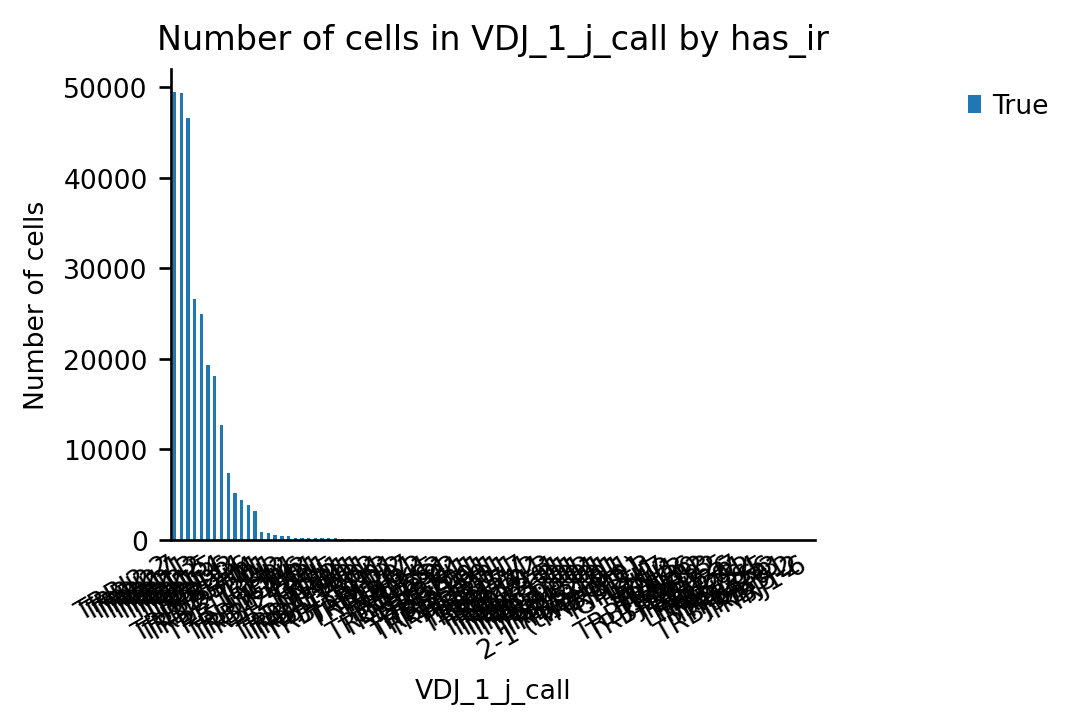

In [7]:
with ir.get.airr_context(adata, "j_call", "VDJ_1"):
    print(adata.obs.columns)
    _= ir.pl.group_abundance(adata, groupby="VDJ_1_j_call", max_cols = 0)
    # plt.xticks(rotation=50, ha='right')

In [8]:
ir.pp.ir_dist(mdata, adata, metric="fastalignment", sequence="aa", cutoff = 10)

Computing sequence x sequence distance matrix for VJ sequences.
block size set to 336


  0%|          | 0/1085 [00:00<?, ?it/s]

Computing sequence x sequence distance matrix for VDJ sequences.
block size set to 606


  0%|          | 0/1173 [00:00<?, ?it/s]

Next, cells between query and database are matched based on provided distance calculations and further conditions that can be specified in scirpy.tl.ir_query e.g. matching based on primary (dual_ir = "primary_only) CDRβ (receptor_arms = "VDJ") sequences. For how Scirpy handles dual TCR please refer to the Immune receptor (IR) model

In [9]:
ir.tl.ir_query(
    mdata,
    adata,
    metric="fastalignment",
    sequence="aa",
    receptor_arms="VDJ",
    dual_ir="primary_only",
)

Initializing lookup tables. 
Computing clonotype x clonotype distances.
Stored IR distance matrix in `adata.uns["ir_query_Iggytop_aa_fastalignment"]`.


Cells from the single-cell data are annotated with matched entries of the database based on selected conditions. Setting stategy = "most-frequent" reduces ambiguous assignments, but might reduce accuracy as well, as it will assign the most frequent match even if there are multiple different matches. Here, only one interesting column was included as annotation, although VDJdb contains much more information. This can be specified with the parameter include_ref_cols:

In [10]:
ir.tl.ir_query_annotate(
    mdata,
    adata,
    metric="fastalignment",
    sequence="aa",
    strategy = "most-frequent",
    include_ref_cols=["antigen_name"],
)

  0%|          | 0/1053 [00:00<?, ?it/s]

Stored result in `mdata.obs["airr:antigen_name"]`.


/home/dego/iggytop/.venv/lib/python3.11/site-packages/scirpy/tl/_ir_query.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return values[0]


/home/dego/iggytop/.venv/lib/python3.11/site-packages/scirpy/pl/_clonotypes.py:179: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if f"X_{basis}" not in params.adata.obsm_keys():


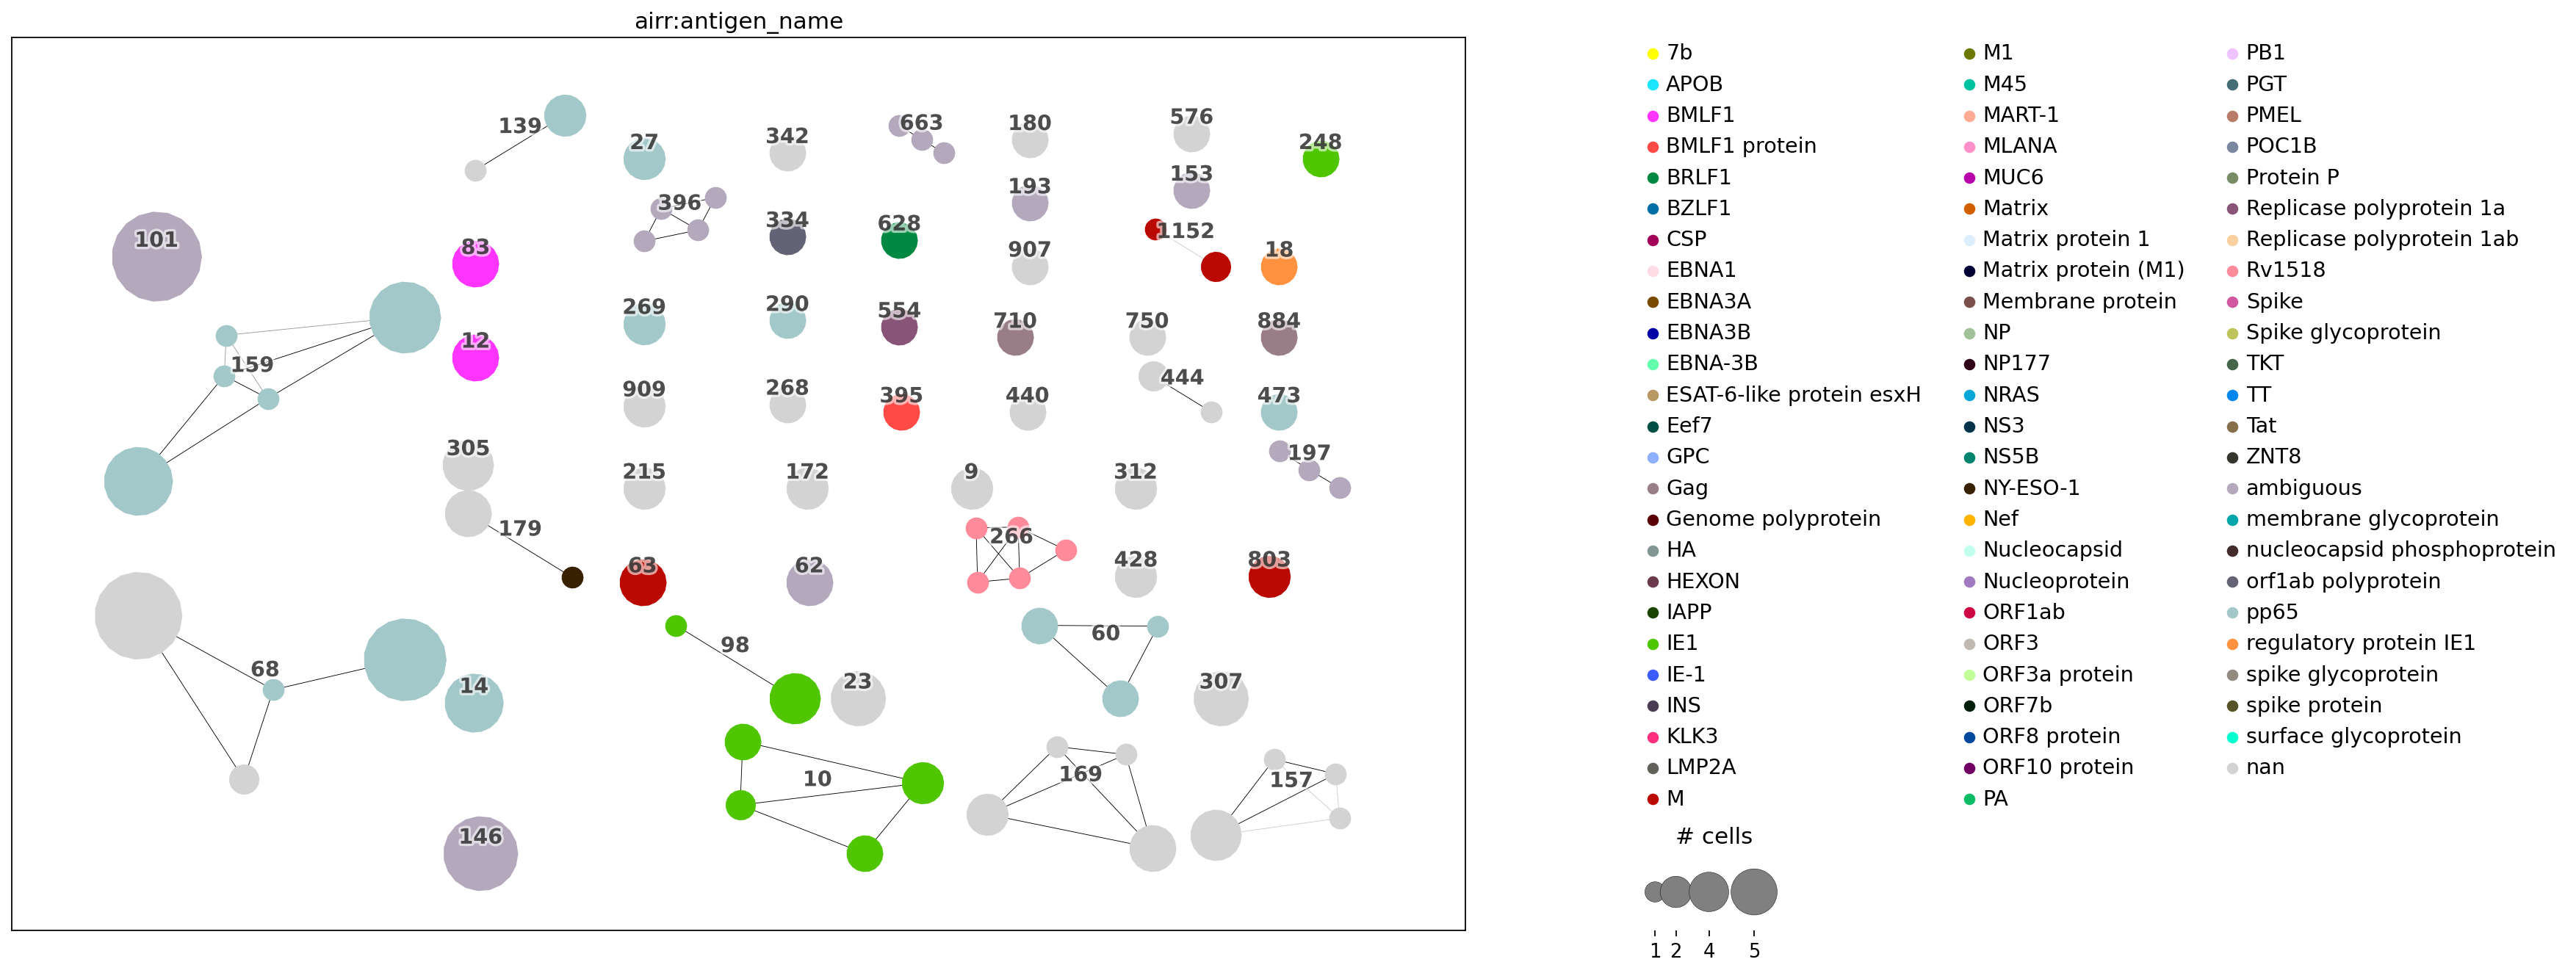

In [11]:
_=ir.pl.clonotype_network(mdata, color="airr:antigen_name", panel_size=(17, 10), show_legend=True)

In [12]:
ir.tl.ir_query_annotate(
    mdata,
    adata,
    metric="fastalignment",
    sequence="aa",
    strategy = "most-frequent",
    include_ref_cols=["antigen_species"],
)

  0%|          | 0/1053 [00:00<?, ?it/s]

Stored result in `mdata.obs["airr:antigen_species"]`.


/home/dego/iggytop/.venv/lib/python3.11/site-packages/scirpy/tl/_ir_query.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return values[0]


/home/dego/iggytop/.venv/lib/python3.11/site-packages/scirpy/pl/_clonotypes.py:179: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if f"X_{basis}" not in params.adata.obsm_keys():


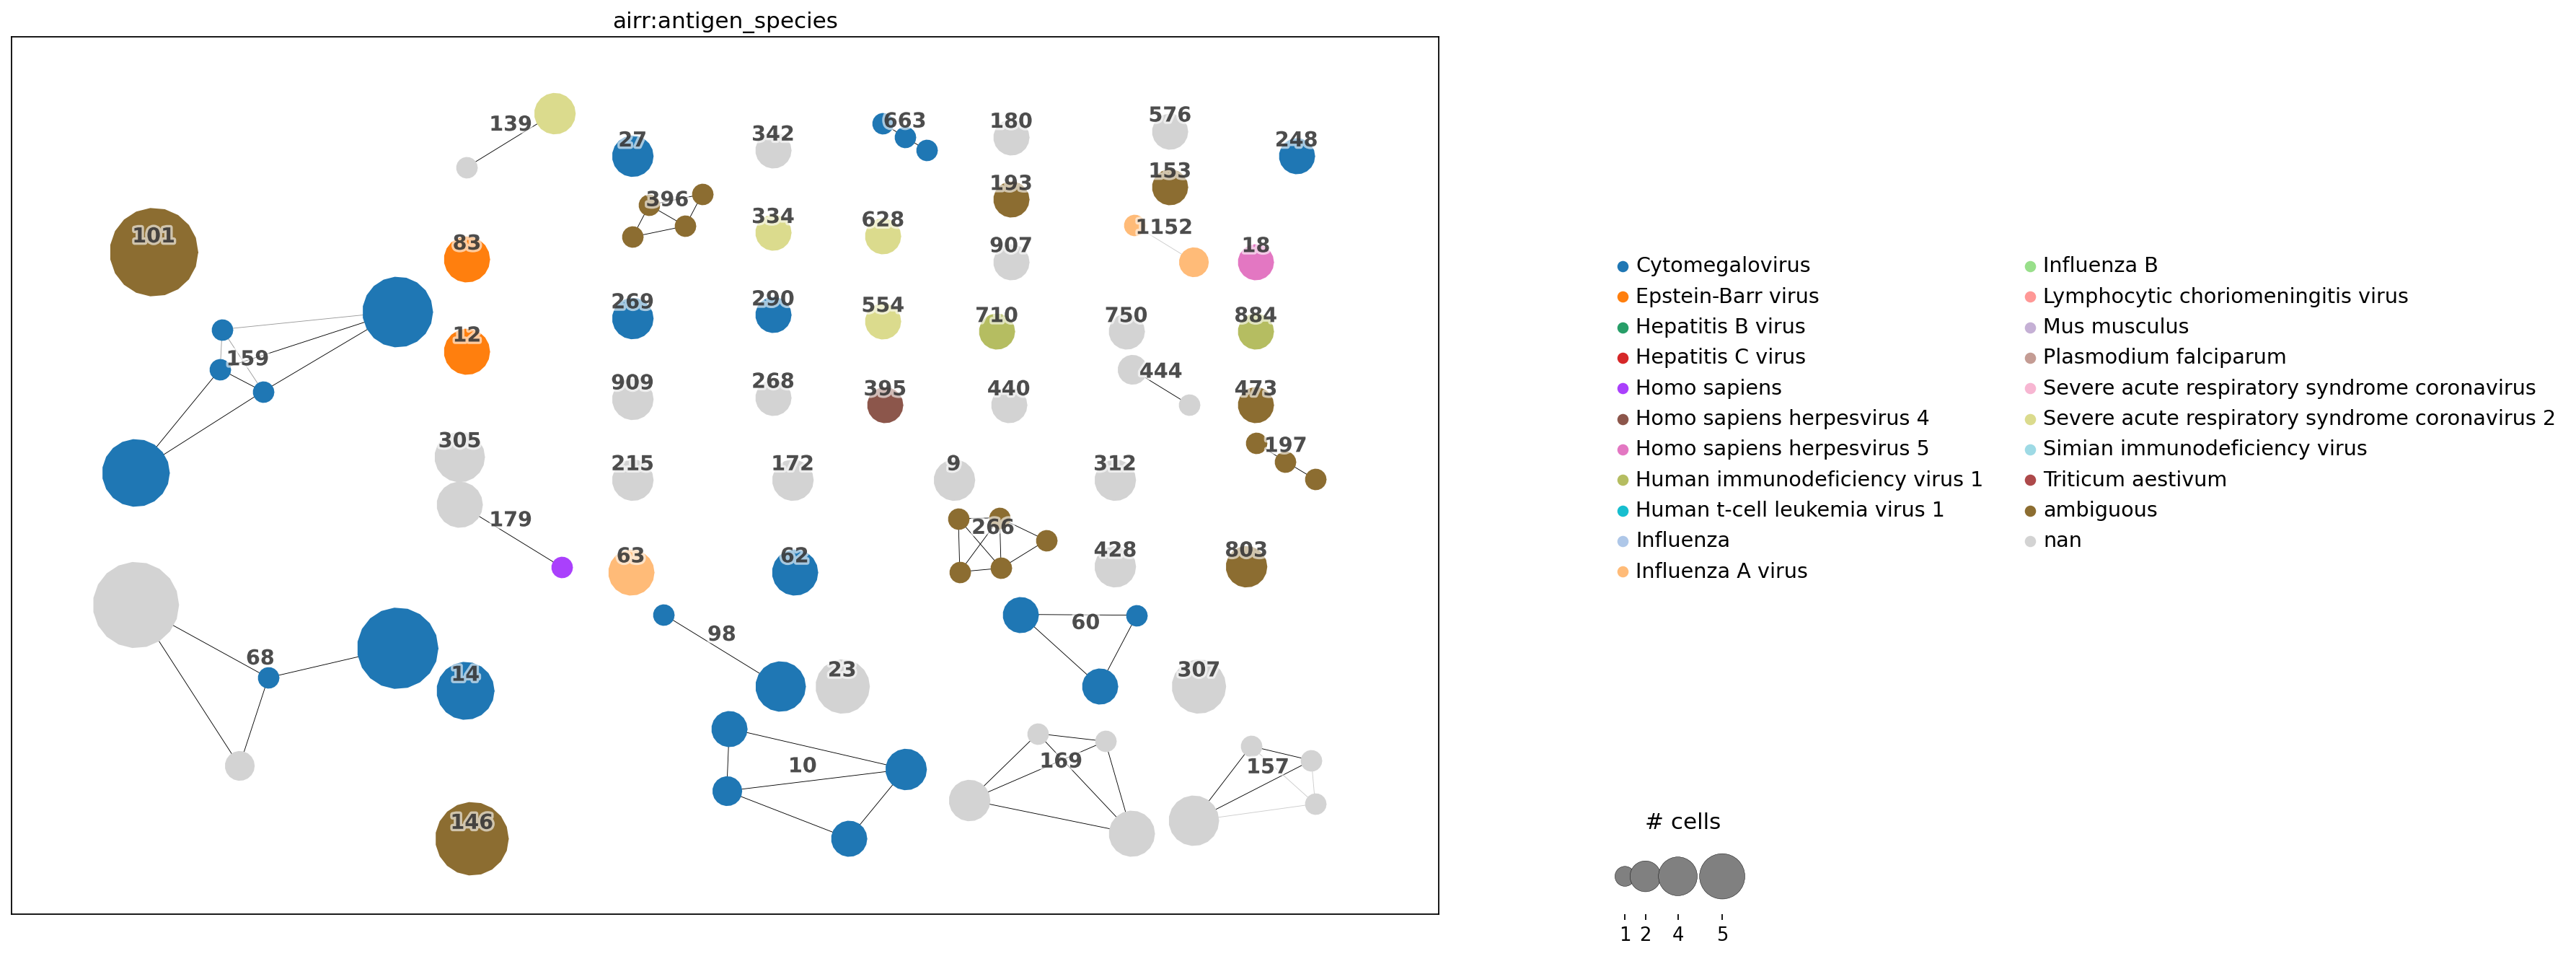

In [13]:
_=ir.pl.clonotype_network(mdata, color="airr:antigen_species", panel_size=(17, 10), show_legend=True)

In [14]:
adata

AnnData object with n_obs × n_vars = 343562 × 0
    obs: 'MHC_gene_1', 'PMID', 'antigen_name', 'antigen_species', 'epitope_sequence', 'iedb_iri', 'source_organism', 'tissue', 'MHC_gene_2', 'MHC_class', 'source'
    uns: 'chain_indices', 'iggytop_metadata', 'DB'
    obsm: 'airr', 'chain_indices'

In [15]:
ir.tl.ir_query_annotate(
    mdata,
    adata,
    metric="fastalignment",
    sequence="aa",
    strategy = "most-frequent",
    include_ref_cols=["source"],
)

  0%|          | 0/1053 [00:00<?, ?it/s]

Stored result in `mdata.obs["airr:source"]`.


/home/dego/iggytop/.venv/lib/python3.11/site-packages/scirpy/tl/_ir_query.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return values[0]


/home/dego/iggytop/.venv/lib/python3.11/site-packages/scirpy/pl/_clonotypes.py:179: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if f"X_{basis}" not in params.adata.obsm_keys():


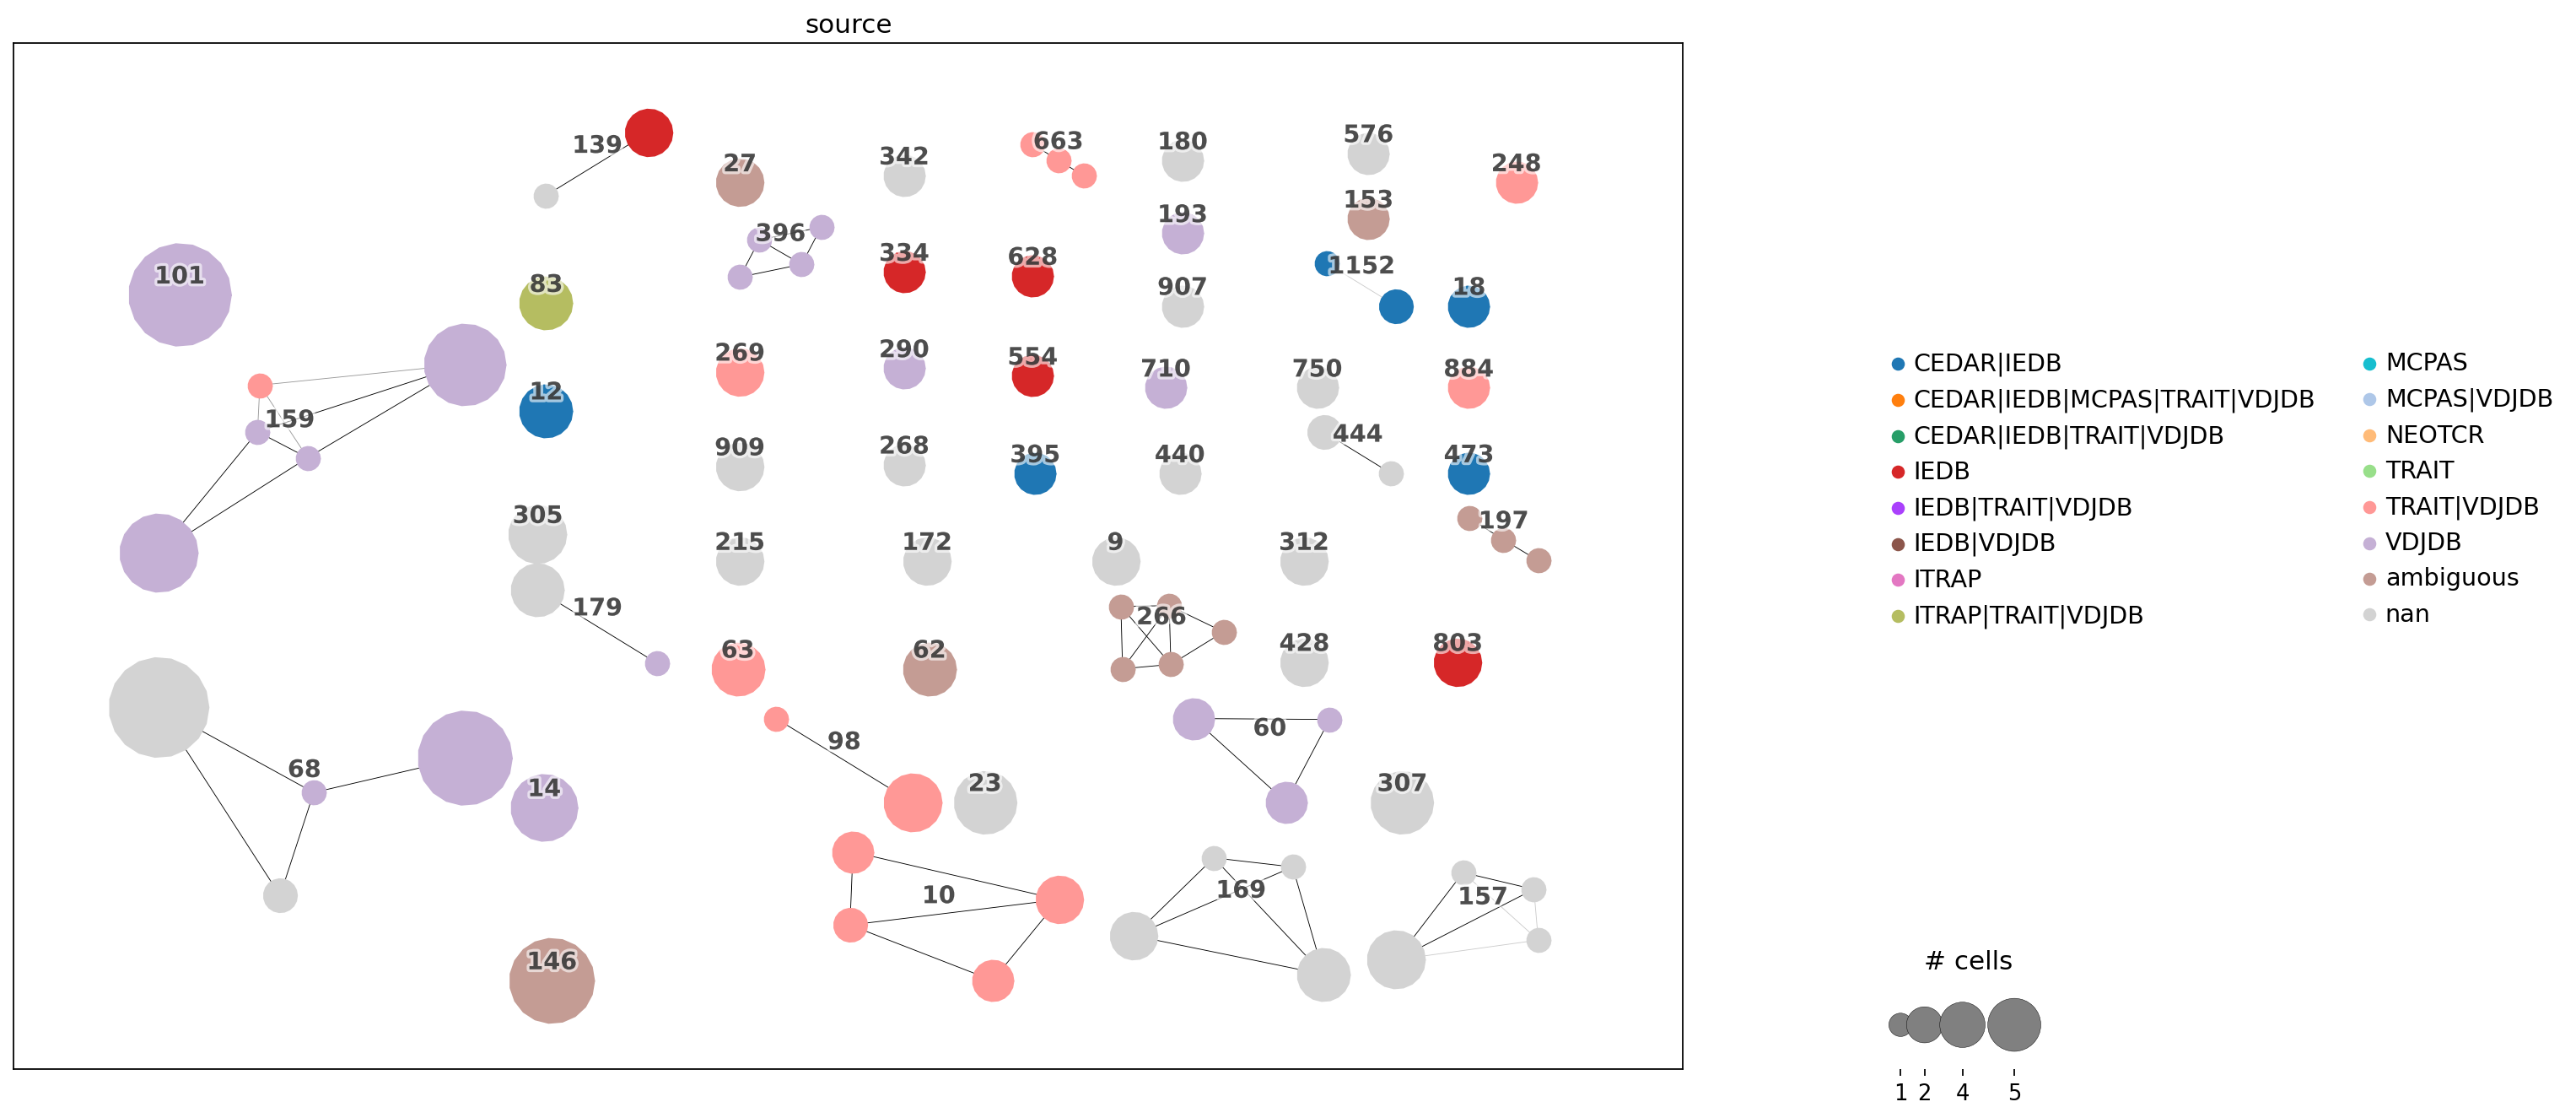

In [16]:
_=ir.pl.clonotype_network(mdata, color="source", panel_size=(17, 10), show_legend=True)